In [21]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
from GNB.gaussian_naive_bayes import GNB
from LogisticRegresssion.LogisticRegression import LogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score
from sklearn.model_selection import train_test_split



In [22]:
#Download Data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


In [23]:
y_train_bin = (y_train == 6).astype(int)
y_test_bin  = (y_test == 6).astype(int)


In [24]:
# Flatten
# X_train = X_train.reshape(X_train.shape[0], -1)
# X_test = X_test.reshape(X_test.shape[0], -1)

In [25]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [26]:
def compute_pixel_variance(X):
    mean = np.mean(X, axis=0)
    return np.mean((X - mean) ** 2, axis=0)

def variance_threshold(X, threshold=1e-4):
    variances = compute_pixel_variance(X)
    mask = variances > threshold
    return X[:, mask], mask

X_train_clean, mask = variance_threshold(X_train)
X_test_clean = X_test[:, mask]

print("After variance filtering:", X_train_clean.shape)


After variance filtering: (60000, 623)


In [27]:
import numpy as np
from skimage.feature import hog

def extract_hog_features(X):
    features = []

    for img in X:
        img_2d = img.reshape(28, 28)

        hog_features = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )

        features.append(hog_features)

    return np.array(features)

In [29]:
X_train_HOG = extract_hog_features(X_train)
X_test_HOG = extract_hog_features(X_test)

In [30]:
pca = PCA(n_components=50)  

X_train_hog_pca = pca.fit_transform(X_train_HOG)
X_test_hog_pca = pca.transform(X_test_HOG)

In [31]:
print(X_test_hog_pca.shape)

(10000, 50)


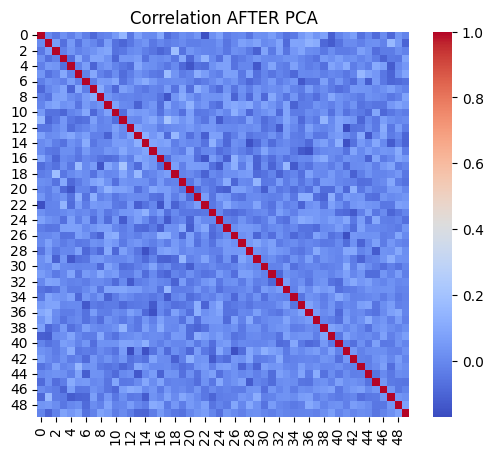

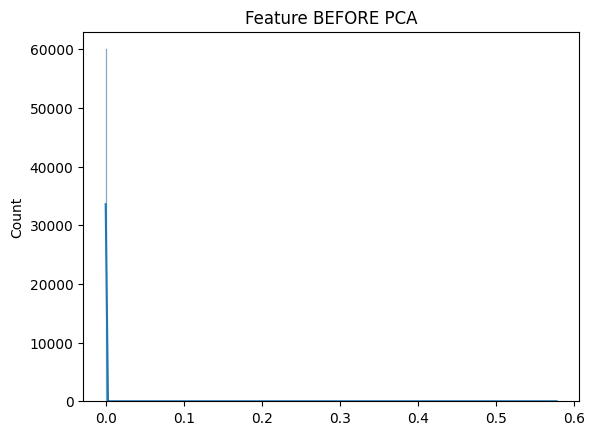

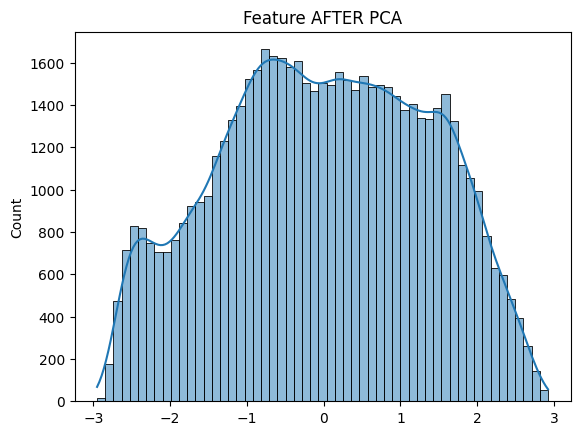

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
X_sample_pca = X_train_hog_pca[:500]

corr_pca = np.corrcoef(X_sample_pca, rowvar=False)

plt.figure(figsize=(6,5))
sns.heatmap(corr_pca, cmap='coolwarm')
plt.title("Correlation AFTER PCA")
plt.show()


sns.histplot(X_train_HOG[:,0], kde=True)
plt.title("Feature BEFORE PCA")
plt.show()

sns.histplot(X_train_hog_pca[:,0], kde=True)
plt.title("Feature AFTER PCA")
plt.show()

In [13]:
from sklearn.model_selection import KFold
def run_kfold(X, y, train_fn, predict_fn, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for i, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]

        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        model = train_fn(X_train_fold, y_train_fold)
        preds = predict_fn(model, X_val_fold)

        score = f1_score(y_val_fold, preds, pos_label=1)
        scores.append(score)

        print(f"Fold {i+1} → F1: {score:.4f}")

    avg = np.mean(scores)
    print("\nK-Fold Avg F1:", avg)

    return avg, scores

In [ ]:
#Decision Tree results
dt = DecisionTree(maxDepth=12 , minSampleLeafs=5 , minSamplesSplit=10 , criterion='entropy' ,maxFeatures= 'sqrt' , classWeights={0:1 , 1:5} )


dt.fit(X_train_hog_pca , y_train_bin)
predictions = dt.predict(X_test_hog_pca)
print(classification_report(
    y_test_bin, predictions,
    target_names=["Not 6", "Is 6"]
))



              precision    recall  f1-score   support

       Not 6       0.90      1.00      0.95      9042
        Is 6       0.00      0.00      0.00       958

    accuracy                           0.90     10000
   macro avg       0.45      0.50      0.47     10000
weighted avg       0.82      0.90      0.86     10000



c:\Users\domma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\domma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\domma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

: 

In [35]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_hog_pca, y_train_bin,
    test_size=0.2,
    stratify=y_train_bin,
    random_state=42
)

# Train
gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

# Tune weights
best_weight = None
best_score = -1

for w in [1, 1.5, 2, 3, 4, 5, 7, 10]:
    class_weights = {0: 1.0, 1: w}
    preds = gnb.predict(X_val, class_weights=class_weights)
    score = f1_score(y_val, preds, pos_label=1)

    print(f"Weight {w} → F1: {score:.4f}")

    if score > best_score:
        best_score = score
        best_weight = w

print("\n🔥 Best weight:", best_weight)

def train_gnb(X, y):
    gnb = GNB()
    gnb.gaussian_naive_train(X, y)
    return gnb


def predict_gnb(model, X):
    return model.predict(
        X,
        class_weights={0: 1.0, 1: best_weight}
    )


# ======================
# STEP 2: K-FOLD
# ======================
print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train, y_train, train_gnb, predict_gnb, k=5)


# ======================
# STEP 3: FINAL TEST
# ======================
print("\n=== FINAL TEST RESULTS ===")

gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

predictions = gnb.predict(
    X_test_hog_pca,   # ✅ CORRECT
    class_weights={0: 1.0, 1: best_weight}
)

print(classification_report(
    y_test_bin,
    predictions,
    target_names=["Not 6", "Is 6"]
))


Weight 1 → F1: 0.9324
Weight 1.5 → F1: 0.9392
Weight 2 → F1: 0.9422
Weight 3 → F1: 0.9471
Weight 4 → F1: 0.9513
Weight 5 → F1: 0.9541
Weight 7 → F1: 0.9555
Weight 10 → F1: 0.9549

🔥 Best weight: 7

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.9455
Fold 2 → F1: 0.9568
Fold 3 → F1: 0.9567
Fold 4 → F1: 0.9528
Fold 5 → F1: 0.9508

K-Fold Avg F1: 0.9524957951586179

=== FINAL TEST RESULTS ===
              precision    recall  f1-score   support

       Not 6       0.99      1.00      1.00      9042
        Is 6       0.98      0.93      0.96       958

    accuracy                           0.99     10000
   macro avg       0.99      0.97      0.98     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
lg = LogReg(max_iterations=1000 , learning_rate=0.1 , threshold=0.5)
lg.fit(X_train_hog_pca , y_train_bin)
predictions = lg.predict(X_test_hog_pca)
print(classification_report(
    y_test_bin,
    predictions,
    target_names=["Not 6", "Is 6"]
))

              precision    recall  f1-score   support

       Not 6       0.99      1.00      1.00      9042
        Is 6       0.99      0.94      0.96       958

    accuracy                           0.99     10000
   macro avg       0.99      0.97      0.98     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
y_train_bin = np.where(y_train == 6, 1, -1)
y_test_bin  = np.where(y_test == 6, 1, -1)

In [ ]:
svm = LinearSVMScartch(
    C=1.0,
    learning_rate=0.0001,
    n_epochs=100,
    batch_size=128,
    use_class_weights=True,
    random_state=42
)
svm.fit(X_train_hog_pca , y_train_bin)
predictions = svm.predict(X_test_hog_pca)
print(classification_report(
    y_test_bin,
    predictions,
    target_names=["Not 6", "Is 6"]
))

c:\Users\domma\machine_mnist\Machine-Learning-Number-Classification_MNIST\SVM\linear_svm.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  weight_pos = n_samples / (2.0 * n_pos)


IndexError: index 51012 is out of bounds for axis 0 with size 48000